## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [34]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
%pip install requests tqdm gdown

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data
from pathlib import Path
import gdown
# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1SXcJvoOo5uEGYC9gJBDOOC_fSFXXb4ht', 'filename':'reddit_dead_internet_analysis_2026.csv'},
    # { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]
get_data.get_raw(datafiles,destination_directory='data/00-raw/')

# using gdown to download a large google drive file to put into 00-raw directory
dest = Path('data/00-raw/AI_vs_Human_combined.csv')
if not dest.exists():
    print("Downloading AI_vs_Human_combined.csv...")
    gdown.download(
        id='1QTvrMNkqpSlwkwpTjva9TKckh9VZrpH8',
        output=str(dest),
        fuzzy=True
    )
    print("Done → data/00-raw/AI_vs_Human_combined.csv")
else:
    print("AI_vs_Human_combined.csv already exists, skipping.")
    

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Overall Download Progress: 100%|██████████| 1/1 [00:01<00:00,  1.08s/it]                       

Successfully downloaded: reddit_dead_internet_analysis_2026.csv
AI_vs_Human_combined.csv already exists, skipping.


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [4]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [5]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE

# load dataset
reddit_df = pd.read_csv('data/00-raw/reddit_dead_internet_analysis_2026.csv')

In [8]:
# make dataset tidy or demonstrate that it is already tidy
cleaned_reddit_df = reddit_df.dropna(how = 'all').copy()

account_map = {
    'AI Summarizer':'bot',
    'Reprint Bot':'bot',
    'Engagement Farmer':'bot',
    'None (Human)':'human'
}

cleaned_reddit_df['account_type'] = cleaned_reddit_df['bot_type_label'].map(account_map)

# removing variables we don't need/are redundant
cleaned_reddit_df.drop(['bot_type_label', 'is_bot_flag', 'contains_links'], axis = 1, inplace = True)
cleaned_reddit_df.head(5)

,comment_id,subreddit,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,bot_probability,account_type
0,t1_3148938807,funny,2264,34192,1854,-0.60,4.62,0.093,human
1,t1_2516748923,gaming,1654,2812,1033,0.15,5.84,0.117,human
2,t1_833922318,politics,2442,37109,2703,0.35,5.73,0.115,human
3,t1_3987809057,funny,168,32997,2811,-0.74,4.58,0.094,human
4,t1_3931039688,gaming,801,25088,1721,-0.96,5.78,0.116,human


In [9]:
# demonstrate the size of the dataset
cleaned_reddit_df.size
cleaned_reddit_df

,comment_id,subreddit,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,bot_probability,account_type
0,t1_3148938807,funny,2264,34192,1854,-0.60,4.62,0.093,human
1,t1_2516748923,gaming,1654,2812,1033,0.15,5.84,0.117,human
2,t1_833922318,politics,2442,37109,2703,0.35,5.73,0.115,human
3,t1_3987809057,funny,168,32997,2811,-0.74,4.58,0.094,human
4,t1_3931039688,gaming,801,25088,1721,-0.96,5.78,0.116,human
...,...,...,...,...,...,...,...,...,...
495,t1_2488854300,technology,12,21283,1,-0.21,6.35,0.358,bot
496,t1_4130800481,technology,2178,43090,5,0.71,5.78,0.182,bot
497,t1_3088776262,pics,2672,20283,1555,0.21,4.85,0.097,human
498,t1_3049062501,pics,2227,4322,1868,-0.38,5.48,0.110,human


In [14]:
# find out how much data is missing and if it is missing at random points or seems to have systematic relationships in its missingness
missing_col_count = cleaned_reddit_df.isnull().sum()
total_count_missing = missing_col_count.sum()
print(f"Missing {total_count_missing} values")

if (total_count_missing == 0):
    print(f"No values missing, we move on")

Missing 0 values
No values missing, we move on


In [13]:
# find and flag any outliers or suspicious entries
# finding numeric columns
numeric_cols = ['account_age_days', 'user_karma', 'reply_delay_seconds', 'sentiment_score', 'avg_word_length', 'bot_probability']

# iqr: flag values outside [Q1 - 1.5*iqr, Q3 + 1.5*iqr] in order to find the outliers
outlier_flags = pd.DataFrame(False, index = cleaned_reddit_df.index, columns = numeric_cols)
print("\nnumber of outliers from iqr test:")
for col in numeric_cols:
    q1, q3 = cleaned_reddit_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    flag = (cleaned_reddit_df[col] < q1 - 1.5*iqr) | (cleaned_reddit_df[col] > q3 + 1.5*iqr)
    outlier_flags[col] = flag
    print(f"{col:<25}:{flag.sum():>3} outlier(s)")

# mark rows with any outlier
cleaned_reddit_df['is_outlier'] = outlier_flags.any(axis=1)

# check the flagged rows
outlier_rows = cleaned_reddit_df[cleaned_reddit_df['is_outlier']][numeric_cols]
print(f"\n{len(outlier_rows)} flagged rows")
print(outlier_rows.to_string(index=False))

print('\nall 12 outliers are in bot_probability (>0.35) and share a clear pattern: very new accounts (age 1–27 days) are labelled as bots, we can ignore this due to common sense')


number of outliers from iqr test:
account_age_days         :  0 outlier(s)
user_karma               :  0 outlier(s)
reply_delay_seconds      :  0 outlier(s)
sentiment_score          :  0 outlier(s)
avg_word_length          :  0 outlier(s)
bot_probability          : 12 outlier(s)

12 flagged rows
 account_age_days  user_karma  reply_delay_seconds  sentiment_score  avg_word_length  bot_probability
                1       27834                    8            -0.88             5.70            0.358
                1       11730                    2            -0.47             6.60            0.465
                1       39727                    3             0.17             6.11            0.422
                3       46307                    1            -0.08             6.68            0.434
               27       15472                    1             0.95             7.18            0.358
                5       32711                    1             0.91             6.83      

In [16]:
# clean the data or demonstrate that it was already clean.  You may choose how to deal with missingness (dropna of fillna... how='any' or 'all') and you should justify your choice in some way
# we don't need any null entries as they are not of use to us, plus there aren't any null entries at all in this dataset. for safety, we'll dropna anyways
cleaned_reddit_df = cleaned_reddit_df.dropna(how = 'all')

In [17]:
# write fully wrangled version of dataset to data/02-processed
cleaned_reddit_df.to_csv('data/02-processed/reddit_analysis_2026_wrangled.csv', index = False)


=== numbers summary ===
       account_age_days    user_karma  reply_delay_seconds  sentiment_score  \
count        500.000000    500.000000           500.000000       500.000000   
mean        1157.624000  25248.198000          1030.700000         0.014980   
std          951.766304  14122.969163          1184.411096         0.581127   
min            1.000000    308.000000             1.000000        -1.000000   
25%          163.000000  13427.250000             7.000000        -0.472500   
50%         1092.500000  24778.500000           459.000000         0.020000   
75%         1960.000000  37111.500000          1925.000000         0.502500   
max         2996.000000  49734.000000          3577.000000         1.000000   

       avg_word_length  bot_probability  
count       500.000000       500.000000  
mean          5.654300         0.156530  
std           0.895203         0.074555  
min           4.030000         0.081000  
25%           4.967500         0.101000  
50%        

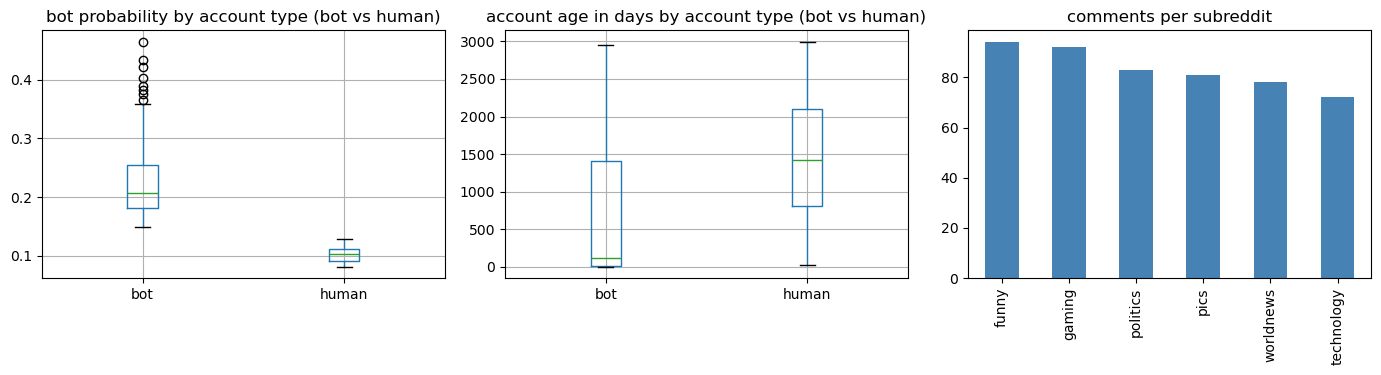

In [18]:
# summary statistics
print("\n=== numbers summary ===")
print(cleaned_reddit_df.select_dtypes('number').describe())

print("\n=== bot probability by account type ===")
print(cleaned_reddit_df.groupby('account_type')['bot_probability'].describe())

print("\n=== account age (days) by account type ===")
print(cleaned_reddit_df.groupby('account_type')['account_age_days'].describe())

print("\n=== subreddit distribution ===")
print(cleaned_reddit_df['subreddit'].value_counts())

# summary visualisations
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cleaned_reddit_df.boxplot(column='bot_probability', by='account_type', ax=axes[0])
axes[0].set_xlabel('')
plt.sca(axes[0]); plt.title('bot probability by account type (bot vs human)')

cleaned_reddit_df.boxplot(column='account_age_days', by='account_type', ax=axes[1])
axes[1].set_xlabel('')
plt.sca(axes[1]); plt.title('account age in days by account type (bot vs human)')

cleaned_reddit_df['subreddit'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('comments per subreddit')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [6]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

# second dataset was too large to export, so i manually uploaded the file into the repo itself under 'AI_vs_Human_combinations.csv' 
# if you can find a way to use the line below to export it here for everyone else, please do orz
# this will act as a sort of temporary solution until then
text_df = pd.read_csv("data/00-raw/AI_vs_Human_combined.csv")

# demonstrate dataset size
print(f"\nRows: {text_df.shape[0]:,}")
print(f"Columns: {text_df.shape[1]}")
print(f"Cells: {text_df.size:,}")


Rows: 717,684
Columns: 3
Cells: 2,153,052


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them